# Read Label Tif Files
This notebook contains code to read in and load a particular label tif file, which helps to understand what values are in the particular file. To use this notebook, enter the relative path of the .tif file of interest into FILE_PATH and run both code cells. 

Note the FILE_PATH has to be the relative path to the file. Example:  `../data/dataset/labels/114_5062566_2019.06.14_JL.tif`

In [2]:
FILE_PATH="/home/waves/data/smallholder-irrigation-dataset/data/dataset/labels/114_5062566_2019.06.14_JL_label.tif"
SAT_FILE_PATH = "/home/waves/data/smallholder-irrigation-dataset/data/features_v2/_tmp_tif/site_-11.16_28.86_2019_114/s2_-11.16_28.86_2019-06-09_2019-06-19.tif"

### Imports

In [41]:
import tifffile
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import rasterio
from rasterio.plot import show
from skimage import measure
from matplotlib.path import Path
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

## Load in Satellite Image

In [5]:
with rasterio.open(SAT_FILE_PATH) as src:
    sat_img = src.read([1, 2, 3])  # Read RGB bands
    sat_transform = src.transform

In [6]:
def _stretch_01(channel_int, p_lo=2, p_hi=98):
    """
    Percentile stretch of a single channel (int16 reflectance 0..10000).
    Returns float32 0..1; NO_DATA left as NaN for now.
    """
    ch = channel_int.astype(np.float32) / 10000.0
    mask = (channel_int == -9999)
    vals = ch[~mask]
    if vals.size == 0:
        out = np.zeros_like(ch, dtype=np.float32)
        out[mask] = np.nan
        return out

    lo, hi = np.percentile(vals, (p_lo, p_hi))
    if hi <= lo + 1e-6:
        # Avoid divide-by-zero
        out = np.clip(ch, 0.0, 1.0)
    else:
        out = (ch - lo) / (hi - lo)
        out = np.clip(out, 0.0, 1.0)
    out[mask] = np.nan
    return out


In [7]:
RGB_P_LO, RGB_P_HI = 2, 98
r = _stretch_01(sat_img[2], RGB_P_LO, RGB_P_HI)
g = _stretch_01(sat_img[0], RGB_P_LO, RGB_P_HI)
b = _stretch_01(sat_img[1], RGB_P_LO, RGB_P_HI)

rgb = np.stack([r, g, b], axis=-1)  # (H,W,3)

In [8]:
rgb = np.where(np.isnan(rgb), 0, rgb)  # Replace NaNs with 0 for visualization
rgb

array([[[0.64984643, 0.6267943 , 0.4938272 ],
        [0.39983204, 0.35645932, 0.35802472],
        [0.20707294, 0.16985646, 0.1234568 ],
        ...,
        [0.3339886 , 0.29904306, 0.12522046],
        [0.3292173 , 0.24880382, 0.1340388 ],
        [0.24142605, 0.16985646, 0.07936507]],

       [[0.26623663, 0.20334929, 0.13580248],
        [0.25955686, 0.24162678, 0.2186949 ],
        [0.27577916, 0.23684211, 0.15343916],
        ...,
        [0.31776628, 0.19617225, 0.12698413],
        [0.32253754, 0.21052632, 0.13227513],
        [0.25860262, 0.15789473, 0.11287478]],

       [[0.22997501, 0.1076555 , 0.08641975],
        [0.14981773, 0.05502392, 0.05114638],
        [0.2671909 , 0.19617225, 0.1622575 ],
        ...,
        [0.3587992 , 0.27033493, 0.2186949 ],
        [0.42464262, 0.39952153, 0.33862436],
        [0.40269482, 0.35885167, 0.31040564]],

       ...,

       [[0.24715157, 0.13157895, 0.09876543],
        [0.18130809, 0.11244019, 0.07054674],
        [0.0629807 , 0

## Load in Label TIF

In [9]:
# Load TIF file
with tifffile.TiffFile(FILE_PATH) as tif:
    image = tif.asarray()

# Ensure shape is (8, 100, 100)
if image.shape[-1] == 8:
    image = np.transpose(image, (2, 0, 1))

In [10]:
image.shape

(8, 100, 100)

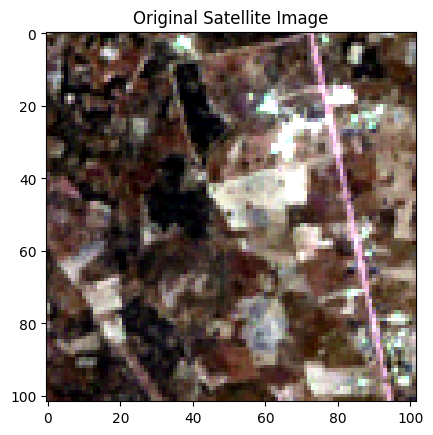

In [11]:
plt.imshow(rgb)
plt.title('Original Satellite Image')
plt.show()

## Plot Label TIF on top of Satellite Image

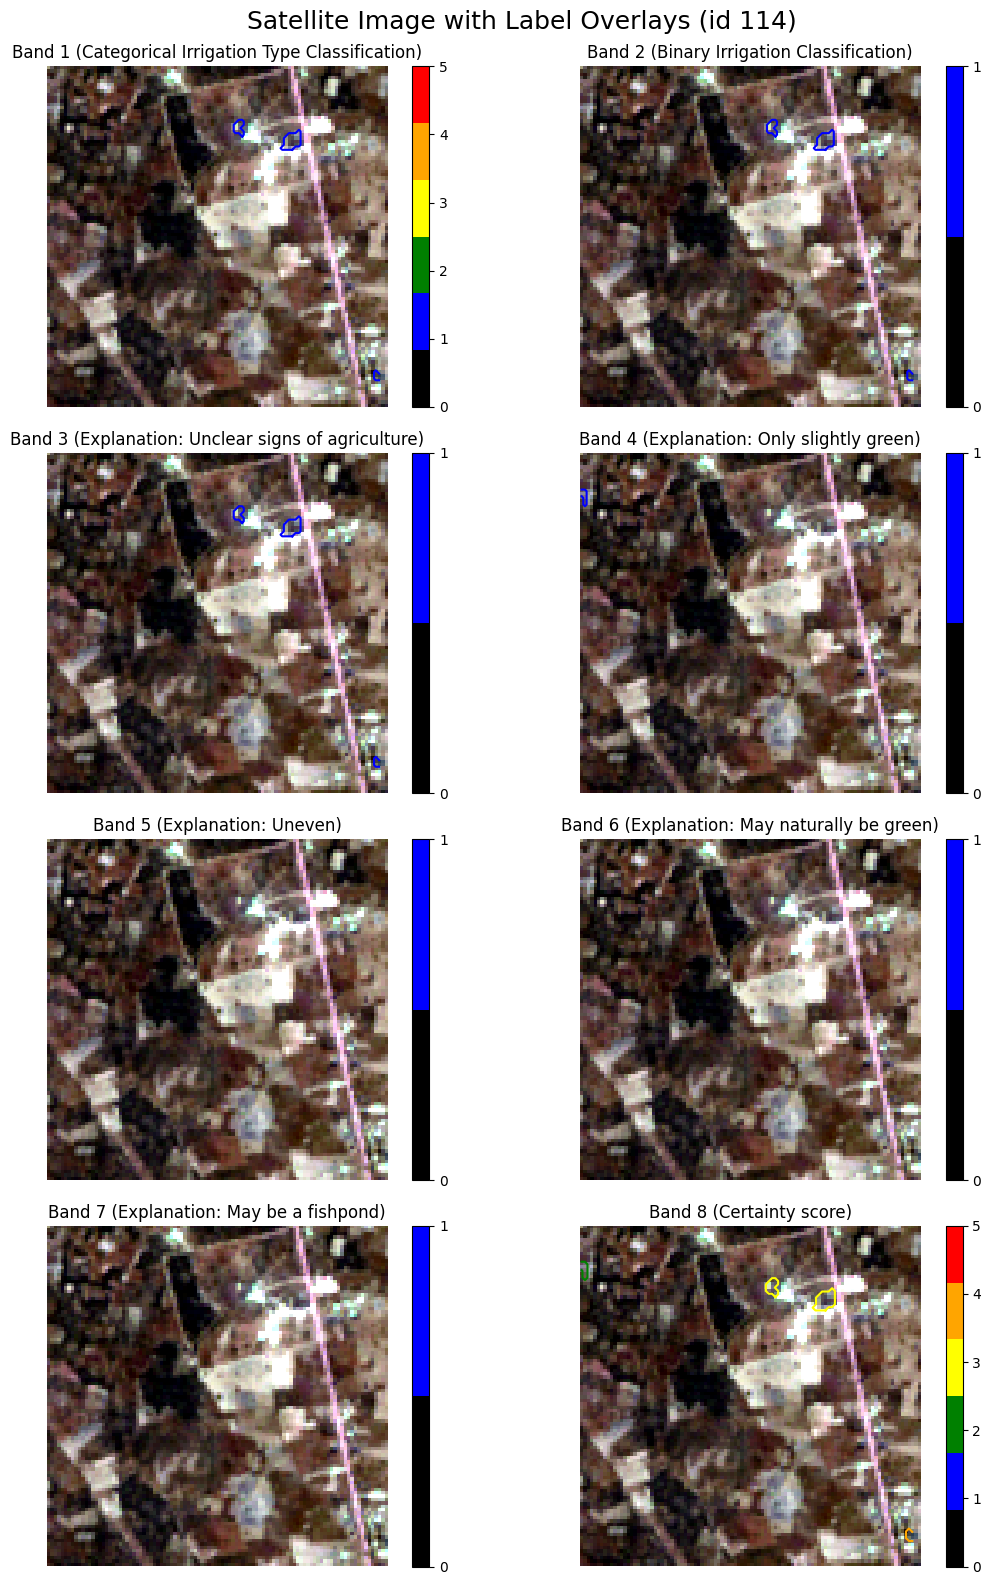

In [43]:
# Define discrete colormap for class values (e.g., 0–5)
colors = ['black', 'blue', 'green', 'yellow', 'orange', 'red']
cmap = ListedColormap(colors)

# Create a 4x2 grid for plotting 8 bands
fig, axes = plt.subplots(4, 2, figsize=(12, 16))  # Width x Height in inches
axes = axes.flatten()

band_dict = {
    1: "Categorical Irrigation Type Classification",
    2: "Binary Irrigation Classification",
    3: "Explanation: Unclear signs of agriculture",
    4: "Explanation: Only slightly green",
    5: "Explanation: Uneven",
    6: "Explanation: May naturally be green",
    7: "Explanation: May be a fishpond",
    8: "Certainty score"
}

# Plot each band
fig.suptitle("Satellite Image with Label Overlays (id 114)", fontsize=18, x=0.6, va='center')
for i in range(8):
    ax = axes[i]
    ax.imshow(rgb)  # draw satellite background

    label_band = image[i]
    masked_label = np.ma.masked_where(label_band == 0, label_band)
    len_colors = len(colors) if i == 7 or i == 0 else 2

    cmap = ListedColormap(colors[:len_colors])


    im = ax.imshow(masked_label, cmap=cmap, vmin=0, vmax=len_colors - 1, alpha=0)

    # --- Draw outlines around labeled regions, colored by dominant pixel value ---
    contours = measure.find_contours(label_band, level=0.5)

    for contour in contours:
        path = Path(contour)

        # Get all pixel coordinates
        y, x = np.mgrid[0:label_band.shape[0], 0:label_band.shape[1]]
        coords = np.vstack((y.flatten(), x.flatten())).T

        # Find pixels inside the contour
        inside = path.contains_points(coords).reshape(label_band.shape)
        vals_inside = label_band[inside]
        vals_inside = vals_inside[vals_inside > 0]
        if len(vals_inside) == 0:
            continue

        # Find the most common class (dominant value)
        cls = np.bincount(vals_inside.astype(int)).argmax()

        # Get corresponding color from cmap
        color = cmap(cls / (len_colors - 1))[:3]

        # Draw the outline with that color
        ax.plot(contour[:, 1], contour[:, 0], color=color, linewidth=1.5)

    from matplotlib.cm import ScalarMappable
    mappable = ScalarMappable(norm=Normalize(vmin=0, vmax=len_colors - 1), cmap=cmap)
    cbar = fig.colorbar(mappable, ax=ax, fraction=0.046, pad=0.04, ticks=range(len_colors))

    ax.set_title(f'Band {i+1} ({band_dict[i+1]})')
    ax.axis('off')

plt.tight_layout()
plt.show()